
# LASSO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix, recall_score

In [3]:
# 1. Load dataset
df = pd.read_csv('data/df_features_with_labels.csv')

In [4]:
# 2. Convert bubble label to numerical labels
bubble_map = {
    'Not Bubble': 0,
    'Bubble Creation': 1,
    'Bubble Collapse': 2
}

df['gsadf_map_95'] = df['gsadf_label_95'].map(bubble_map)
df['gsadf_map_90'] = df['gsadf_label_90'].map(bubble_map)

In [5]:
# 3. Create rest of Fear & Greed binary columns (for Fear + Greed)
idx = df.columns.get_loc("extreme_fear")

df.insert(idx + 1, "greed", (df['fear_greed_classification'] == 'Greed').astype(int))
df.insert(idx + 1, "fear", (df['fear_greed_classification'] == 'Fear').astype(int))

In [6]:
# 4. Drop redundant columns and columns with ALL NA values
columns_to_exclude = ['gsadf_label_95', 'gsadf_label_90', 'fear_greed_classification']
df = df.drop(columns=columns_to_exclude)
df = df.dropna(axis=1, how='all')

In [7]:
# 5. Lead the label by 1 day, use yesterday's data to predict today, remove NA
df['gsadf_map_90_lead'] = df.groupby('symbol')['gsadf_map_90'].shift(-1)
df['gsadf_map_95_lead'] = df.groupby('symbol')['gsadf_map_95'].shift(-1)

df = df.dropna(subset=['gsadf_map_90_lead'])
df = df.dropna(subset=['gsadf_map_95_lead'])

df['gsadf_map_90_lead'] = df['gsadf_map_90_lead'].astype(int)
df['gsadf_map_95_lead'] = df['gsadf_map_95_lead'].astype(int)

In [8]:
df

,date,open,high,low,close,volume,symbol,buy_bitcoin_trend,crypto_crash_trend,bitcoin_price_trend,...,day_of_week,month,quarter,year,is_month_start,is_month_end,gsadf_map_95,gsadf_map_90,gsadf_map_90_lead,gsadf_map_95_lead
0,2018-05-01,0.34145,0.36034,0.31870,0.35504,1.203687e+08,ADA,4.0,0.0,60.0,...,1,5,2,2018,1,0,0,0,0,0
1,2018-05-02,0.35498,0.37586,0.34500,0.37199,6.545769e+07,ADA,4.0,0.0,58.0,...,2,5,2,2018,0,0,0,0,0,0
2,2018-05-03,0.37199,0.38850,0.36402,0.36716,8.832641e+07,ADA,5.0,0.0,62.0,...,3,5,2,2018,0,0,0,0,0,0
3,2018-05-04,0.36683,0.36897,0.34650,0.35800,5.606927e+07,ADA,4.0,0.0,68.0,...,4,5,2,2018,0,0,0,0,0,0
4,2018-05-05,0.35840,0.37434,0.35771,0.36502,4.696269e+07,ADA,4.0,0.0,62.0,...,5,5,2,2018,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13359,2024-12-27,188.46000,194.39000,182.74000,184.22000,1.946510e+06,SOL,5.0,0.0,99.0,...,4,12,4,2024,0,0,0,0,0,0
13360,2024-12-28,184.22000,196.10000,183.82000,195.50000,1.494848e+06,SOL,4.0,0.0,75.0,...,5,12,4,2024,0,0,0,0,0,0
13361,2024-12-29,195.50000,197.71000,188.57000,189.94000,1.560190e+06,SOL,4.0,1.0,79.0,...,6,12,4,2024,0,0,0,0,0,0
13362,2024-12-30,189.94000,196.47000,185.89000,191.38000,2.415985e+06,SOL,4.0,0.0,100.0,...,0,12,4,2024,0,0,0,0,0,0


In [9]:
# 6. Standardise each coin's features individually, starting with numerical features
scaler = StandardScaler()
df_scaled = df.copy()

date_cols = ['day_of_week', 'month', 'quarter']
binary_cols = ['is_month_start', 'is_month_end', 'risk_off_signal', 'vix_regime', 'extreme_greed', 'greed', 'extreme_fear', 'fear']
output_cols = ['gsadf_map_95', 'gsadf_map_90', 'gsadf_map_90_lead', 'gsadf_map_95_lead']
not_feature_cols = date_cols + binary_cols + output_cols + ['symbol', 'date', 'year']
feature_cols = [c for c in df.columns if c not in not_feature_cols]

# remove +inf or -inf values to avoid standardiser exploding and use ffill or bfill to replace the value
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df[feature_cols] = df.groupby('symbol')[feature_cols].ffill()
df[feature_cols] = df.groupby('symbol')[feature_cols].bfill()

for coin in df['symbol'].unique():
    mask = df['symbol'] == coin
    df_scaled.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])

/var/folders/cg/05v601f51wvb2d6p32cn40n00000gn/T/ipykernel_53200/2133810614.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.44882583 -0.44882583 -0.44882583 ...  4.26253079  4.32534888
  4.38816697]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])
/var/folders/cg/05v601f51wvb2d6p32cn40n00000gn/T/ipykernel_53200/2133810614.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.50783577 -0.50783577 -0.50783577 ... -0.50783577 -0.50783577
 -0.50783577]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])


In [10]:
# 7. Use cyclical standardisation for date-related columns, drop year
df_scaled['month_sin'] = np.sin(2 * np.pi * df_scaled['month'] / 12)
df_scaled['month_cos'] = np.cos(2 * np.pi * df_scaled['month'] / 12)

df_scaled['day_of_week_sin'] = np.sin(2 * np.pi * df_scaled['day_of_week'] / 7)
df_scaled['day_of_week_cos'] = np.cos(2 * np.pi * df_scaled['day_of_week'] / 7)

df_scaled['quarter_sin'] = np.sin(2 * np.pi * df_scaled['quarter'] / 4)
df_scaled['quarter_cos'] = np.cos(2 * np.pi * df_scaled['quarter'] / 4)

In [62]:
pd.set_option('display.max_columns', None)
df_scaled

,date,open,high,low,close,volume,symbol,buy_bitcoin_trend,crypto_crash_trend,bitcoin_price_trend,altcoin_season_trend,sell_crypto_trend,fed_funds,treasury_10y,vix,m2,cpi,real_rate_10y,fear_greed,ret_1d,ret_7d,ret_14d,ret_30d,log_ret,ma_7,ma_14,ma_30,ma_60,ma_ratio_7_30,ma_ratio_30_60,zscore_30,zscore_60,daily_range,atr_7,atr_14,atr_30,volatility_trend,realized_vol_7,realized_vol_30,volume_ma_7,volume_ma_14,volume_ma_30,volume_ratio_7,volume_ratio_30,volume_change_7d,volume_std_30,volume_zscore,price_volume_corr_30,rsi_7,rsi_14,rsi_30,roc_7,roc_14,roc_30,price_position_30,price_position_60,own_trend,own_trend_ma_7,own_trend_ma_14,own_trend_ma_30,own_trend_std_30,own_trend_zscore,own_trend_change_1d,own_trend_change_7d,own_trend_momentum,trend_price_corr_30,trend_volume_corr_30,trend_price_divergence,buy_bitcoin_zscore,crypto_crash_zscore,altcoin_season_zscore,fomo_fear_ratio,fear_greed_ma_7,fear_greed_ma_14,fear_greed_ma_30,fear_greed_std_30,fear_greed_zscore,fear_greed_change_1d,fear_greed_change_7d,fear_greed_change_14d,fear_greed_momentum,extreme_greed,extreme_fear,fear,greed,greed_streak,fear_streak,sentiment_price_corr_30,sentiment_price_divergence,fed_funds_change_1d,fed_funds_change_7d,fed_funds_change_30d,fed_funds_ma_30,treasury_10y_change_1d,treasury_10y_change_7d,treasury_10y_change_30d,yield_spread,yield_spread_change,vix_change_1d,vix_change_7d,vix_regime,m2_growth_30d,m2_growth_60d,m2_growth_90d,cpi_change_30d,real_rate_change,risk_off_signal,ret_1d_lag_1,ret_7d_lag_1,volume_ratio_30_lag_1,fear_greed_lag_1,rsi_14_lag_1,ret_1d_lag_3,ret_7d_lag_3,volume_ratio_30_lag_3,fear_greed_lag_3,rsi_14_lag_3,ret_1d_lag_7,ret_7d_lag_7,volume_ratio_30_lag_7,fear_greed_lag_7,rsi_14_lag_7,ret_1d_lag_14,ret_7d_lag_14,volume_ratio_30_lag_14,fear_greed_lag_14,rsi_14_lag_14,day_of_week,month,quarter,year,is_month_start,is_month_end,gsadf_map_95,gsadf_map_90,gsadf_map_90_lead,gsadf_map_95_lead,month_sin,month_cos,day_of_week_sin,day_of_week_cos,quarter_sin,quarter_cos
0,2018-05-01,-0.260155,-0.250397,-0.276276,-0.235907,-0.452755,ADA,1.797733,-0.172392,2.070371,-0.108673,-0.217456,-0.331293,0.287083,-0.594840,-10.894823,-5.355385,0.284552,0.393486,-0.032885,-0.121301,-0.145780,-0.249384,-0.006799,-0.272276,-0.270032,-0.257337,-0.258395,-0.161136,-0.207593,-0.140637,-0.172380,0.752922,-0.235264,-0.208228,-0.158462,-0.155493,-0.211154,-0.099154,-0.326314,-0.332249,-0.368494,-0.223632,-0.253538,-0.251559,-0.316198,-0.271637,0.043140,-0.024297,-0.012996,-0.097618,-0.121301,-0.145780,-0.249384,-0.166376,-0.190252,-0.522451,0.127971,0.153802,0.163427,-0.192320,-0.066099,-0.002695,-0.012604,0.058657,-0.116918,0.018578,0.017603,-0.137065,-0.158170,0.003673,-0.150883,-0.063819,-0.059422,-0.080976,-0.209097,0.019973,-0.000393,-0.003105,-0.006321,0.004755,0,0,0,1,-0.448826,-0.507836,-0.044016,-0.009873,-0.024151,-0.063777,-0.130934,-0.117950,0.013521,-0.032969,-0.010322,1.127879,0.013990,-0.037028,-0.046901,0,-0.020127,-1.437813e-02,-0.019028,-0.031175,-0.065154,0,-0.033035,-0.121743,-0.253530,-0.014233,-0.013295,-0.033284,-0.121228,-0.253617,-0.013420,-0.012778,-0.033675,-0.119641,-0.254249,-0.011387,-0.009225,-0.034557,-0.119803,-0.254354,-0.007863,-0.007989,1,5,2,2018,1,0,0,0,0,0,5.000000e-01,-0.866025,0.781831,0.623490,1.224647e-16,-1.0
1,2018-05-02,-0.235661,-0.223497,-0.226235,-0.205224,-0.677293,ADA,1.797733,-0.172392,1.941524,-0.108673,-0.217456,-0.331293,0.287083,-0.521474,0.098166,-0.043402,0.273452,0.212138,0.877950,-0.121301,-0.145780,-0.249384,0.884235,-0.272276,-0.270032,-0.257337,-0.258395,-0.161136,-0.207593,-0.140637,-0.172380,0.104766,-0.235264,-0.208228,-0.158462,-0.155493,-0.211154,-0.099154,-0.326314,-0.332249,-0.368494,-0.223632,-0.253538,-0.251559,-0.316198,-0.271637,0.043140,-0.024297,-0.012996,-0.097618,-0.121301,-0.145780,-0.249384,-0.166376,-0.190252,-0.644011,0.127971,0.153802,0.163427,-0.192320,-0.066099,-0.323047,-0.012604,0.058657,-0.116918,0.018578,0.017603,-0.137065,-0.158170,0.003673,-0.150883,-0.063819,-0.059422

In [12]:
# 8. Train-test split
train_df = df_scaled[df_scaled['date'] < '2024-01-01']
test_df = df_scaled[df_scaled['date'] >= '2024-01-01']

In [13]:
train_df[['symbol', 'gsadf_map_90']].value_counts()

symbol  gsadf_map_90
BTC     0               1696
BNB     0               1655
ADA     0               1624
ETH     0               1606
DOGE    0               1343
SOL     0                916
ETH     1                307
ADA     1                289
BTC     1                276
BNB     1                244
DOGE    1                183
SOL     1                178
BNB     2                172
ADA     2                158
ETH     2                158
SOL     2                144
DOGE    2                115
BTC     2                 99
Name: count, dtype: int64

In [34]:
test_df[['symbol', 'gsadf_map_90_lead']].value_counts()

symbol  gsadf_map_90_lead
ADA     0                    319
ETH     0                    312
DOGE    0                    289
BNB     0                    246
SOL     0                    222
BTC     0                    208
        1                    135
SOL     1                    111
BNB     1                    102
DOGE    1                     76
ETH     1                     49
ADA     1                     47
SOL     2                     33
BTC     2                     23
BNB     2                     18
ETH     2                      5
DOGE    2                      1
Name: count, dtype: int64

In [59]:
# 9. Train multinomial logistic regression with Lasso penalty (1.0 L1-ratio in ElasticNet)
all_cols = df.columns.tolist()
not_x = ['symbol', 'date', 'year', 'gsadf_map_95', 'gsadf_map_90', 'gsadf_map_90_lead', 'gsadf_map_95_lead']
x_cols = [col for col in all_cols if col not in not_x]

X_train = train_df[x_cols]
y_train = train_df['gsadf_map_90_lead'].astype(int)

clf = LogisticRegressionCV(
        penalty='elasticnet',
        solver='saga',
        class_weight='balanced',
        l1_ratios=[1.0],
        cv=5,
        max_iter=5000,
        random_state=42,
        n_jobs=-1 
    )
    
clf.fit(X_train, y_train)

/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viviennetsui/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,Cs,10
,fit_intercept,True
,cv,5
,dual,False
,penalty,'elasticnet'
,scoring,None
,solver,'saga'
,tol,0.0001
,max_iter,5000
,class_weight,'balanced'
,n_jobs,-1


In [80]:
# 10. Evaluate model coefficients
weights_df = pd.DataFrame(
    clf.coef_, 
    columns=x_cols, 
    index=[f'Class_{c}_Weight' for c in clf.classes_]
).T

# Add an "Absolute Importance" column to help with sorting
# This shows which features had the most impact overall across all classes
weights_df['Total_Absolute_Impact'] = weights_df.abs().sum(axis=1)

total_features = len(weights_df)
eliminated_features = weights_df[weights_df['Total_Absolute_Impact'] == 0]
num_eliminated = len(eliminated_features)
num_survivors = total_features - num_eliminated

print(f"--- Feature Selection Summary ---")
print(f"Total Features analyzed: {total_features}")
print(f"Eliminated (Zero Weight): {num_eliminated} ({num_eliminated/total_features:.1%})")
print(eliminated_features.index.tolist())
print("\n")

# Sort by impact (Highest at the top, 0s at the bottom)
weights_df = weights_df.sort_values(by='Total_Absolute_Impact', ascending=False)

print("--- Top 25 Feature Weight Leaderboard ---")
print(weights_df.head(30))

--- Feature Selection Summary ---
Total Features analyzed: 130
Eliminated (Zero Weight): 45 (34.6%)
['open', 'low', 'close', 'altcoin_season_trend', 'sell_crypto_trend', 'treasury_10y', 'cpi', 'ret_1d', 'ret_7d', 'ret_14d', 'log_ret', 'ma_7', 'ma_14', 'ma_60', 'atr_14', 'volume_ma_14', 'volume_ratio_7', 'rsi_14', 'roc_7', 'roc_14', 'price_position_60', 'own_trend_ma_7', 'own_trend_ma_14', 'altcoin_season_zscore', 'fear_greed_ma_14', 'fear_greed_change_1d', 'fear_greed_change_7d', 'extreme_greed', 'fear', 'fed_funds_change_1d', 'vix_change_1d', 'm2_growth_30d', 'm2_growth_90d', 'risk_off_signal', 'ret_7d_lag_1', 'rsi_14_lag_1', 'ret_1d_lag_3', 'ret_7d_lag_3', 'rsi_14_lag_3', 'ret_1d_lag_7', 'ret_7d_lag_7', 'rsi_14_lag_7', 'fear_greed_lag_14', 'is_month_start', 'is_month_end']


--- Top 25 Feature Weight Leaderboard ---
                            Class_0_Weight  Class_1_Weight  Class_2_Weight  \
rsi_30                            0.000000        0.907111       -1.404239   
high          

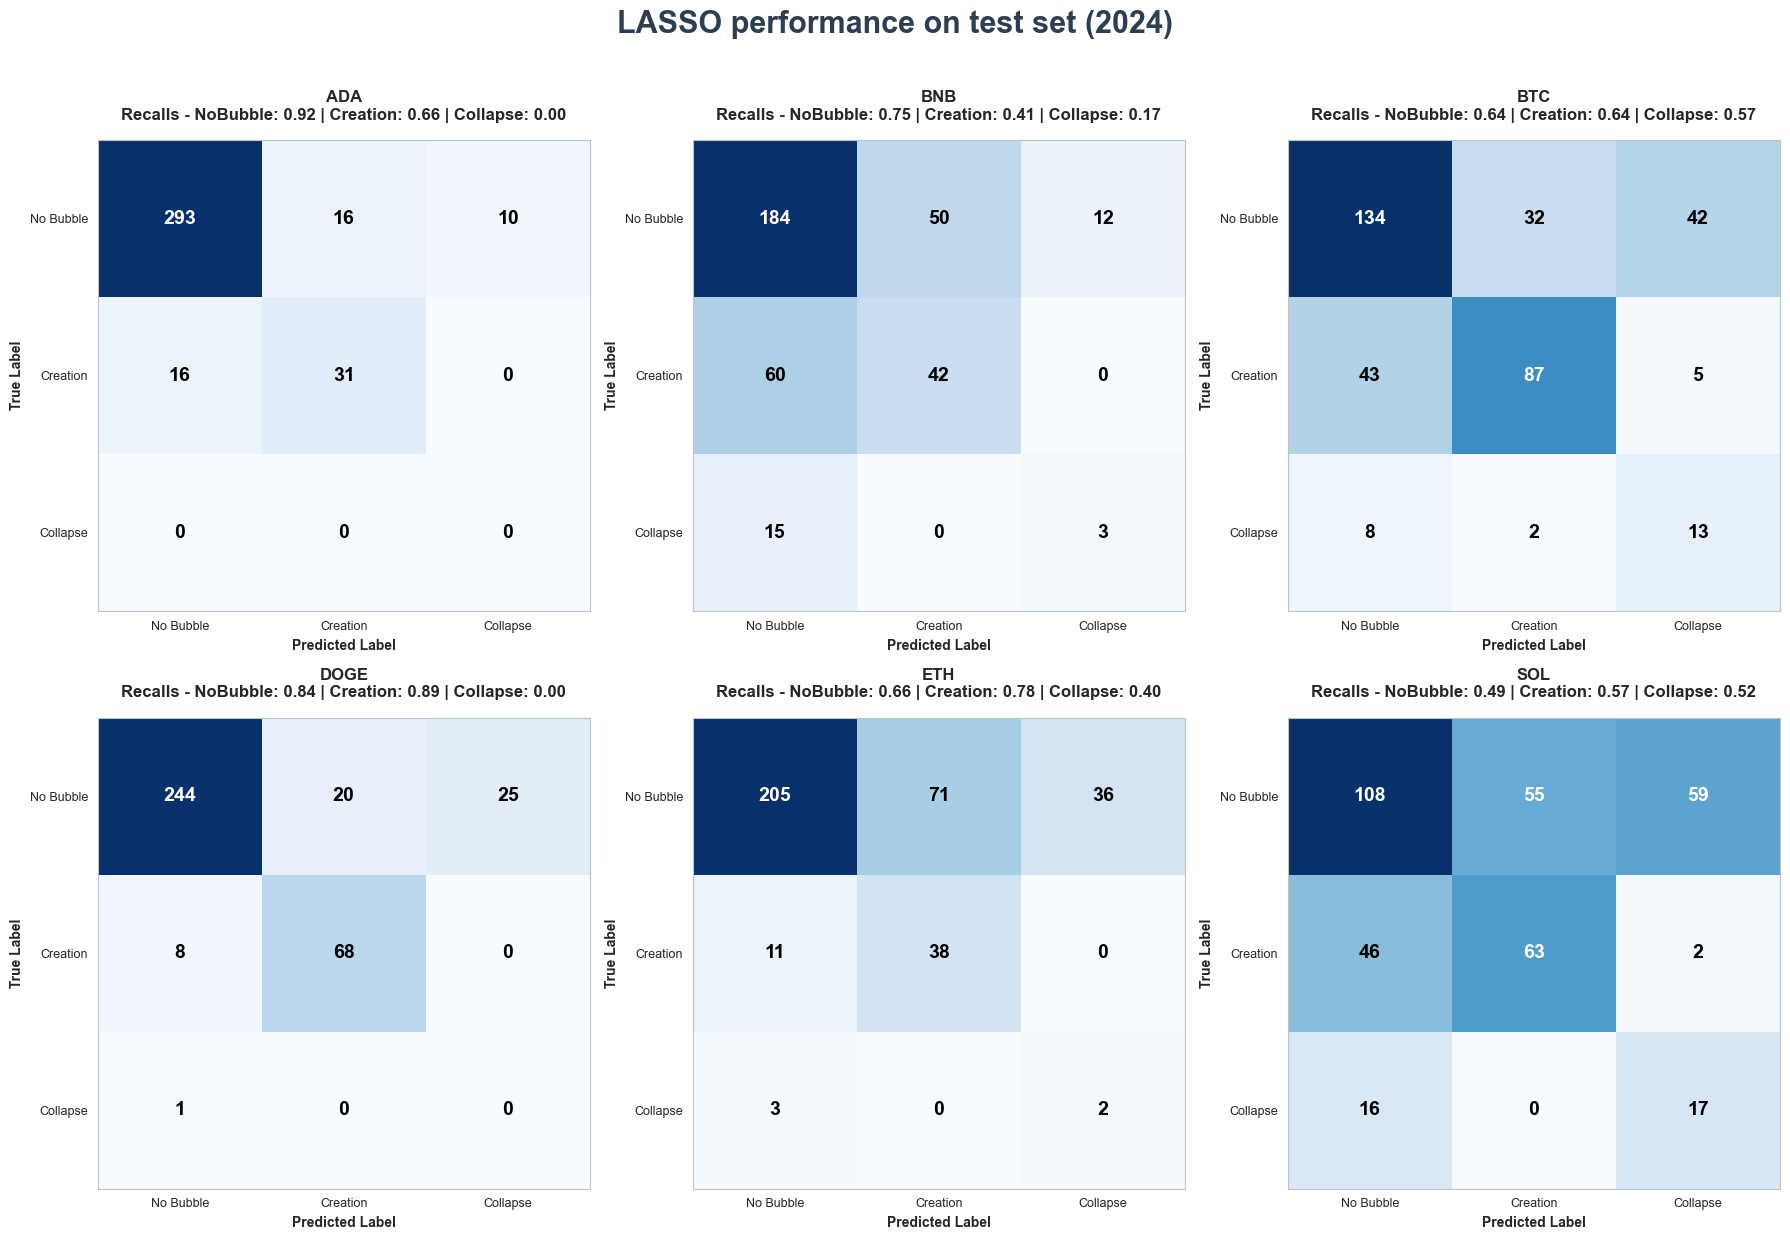

In [92]:
coins = test_df['symbol'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 13))
axes = axes.flatten()

labels = [0, 1, 2]
target_names = ['No Bubble', 'Creation', 'Collapse']

for i, coin in enumerate(coins):
    ax = axes[i]
    
    # Filter test data for the specific coin
    coin_test = test_df[test_df['symbol'] == coin].copy()
    
    # Pre-calculate true vs predicted
    y_true = coin_test['gsadf_map_90_lead'].astype(int)
    y_pred = clf.predict(coin_test[x_cols]).astype(int)
    
    # Create Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Calculate Recalls
    recalls = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    
    # Plotting the Matrix Heatmap
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    ax.grid(False) # Ensure internal gridlines are off
    
    # Add numbers to the boxes
    for row in range(len(labels)):
        for col in range(len(labels)):
            ax.text(col, row, format(cm[row, col], 'd'),
                    ha="center", va="center",
                    color="white" if cm[row, col] > cm.max()/2 else "black",
                    fontsize=14, fontweight='bold')

    # Titles and Recalls
    title_str = (f"{coin}\n"
                 f"Recalls - NoBubble: {recalls[0]:.2f} | Creation: {recalls[1]:.2f} | Collapse: {recalls[2]:.2f}")
    ax.set_title(title_str, fontsize=12, fontweight='bold', pad=15)
    
    # --- ADDED X AND Y LABELS ---
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10, fontweight='bold')
    
    # Tick settings
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(target_names, fontsize=9)
    ax.set_yticklabels(target_names, fontsize=9)
    
    # Clean up axis spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#bdc3c7')

plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.suptitle("LASSO performance on test set (2024)", 
             fontsize=22, fontweight='bold', y=0.98, color='#2c3e50')

plt.savefig('data/outputs/LASSO_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()